In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Load datasets

In [3]:
print("Loading datasets...")

global_temp = pd.read_csv("GlobalTemperatures.csv")
country_temp = pd.read_csv("GlobalLandTemperaturesByCountry.csv")
city_temp = pd.read_csv("GlobalLandTemperaturesByCity.csv")
major_city_temp = pd.read_csv("GlobalLandTemperaturesByMajorCity.csv")
state_temp = pd.read_csv("GlobalLandTemperaturesByState.csv")

Loading datasets...


In [4]:
print("\nSample - GlobalTemperatures:")
print(global_temp.head())


Sample - GlobalTemperatures:
           dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0  1750-01-01                   3.034                              3.574   
1  1750-02-01                   3.083                              3.702   
2  1750-03-01                   5.626                              3.076   
3  1750-04-01                   8.490                              2.451   
4  1750-05-01                  11.573                              2.072   

   LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
0                 NaN                            NaN                 NaN   
1                 NaN                            NaN                 NaN   
2                 NaN                            NaN                 NaN   
3                 NaN                            NaN                 NaN   
4                 NaN                            NaN                 NaN   

   LandMinTemperatureUncertainty  LandAndOceanAverageTem

In [5]:
print("\nSample - GlobalLandTemperaturesByCountry:")
print(country_temp.head())


Sample - GlobalLandTemperaturesByCountry:
           dt  AverageTemperature  AverageTemperatureUncertainty Country
0  1743-11-01               4.384                          2.294   Åland
1  1743-12-01                 NaN                            NaN   Åland
2  1744-01-01                 NaN                            NaN   Åland
3  1744-02-01                 NaN                            NaN   Åland
4  1744-03-01                 NaN                            NaN   Åland


In [6]:
print("\nSample - GlobalLandTemperaturesByCity:")
print(city_temp.head())


Sample - GlobalLandTemperaturesByCity:
           dt  AverageTemperature  AverageTemperatureUncertainty   City  \
0  1743-11-01               6.068                          1.737  Århus   
1  1743-12-01                 NaN                            NaN  Århus   
2  1744-01-01                 NaN                            NaN  Århus   
3  1744-02-01                 NaN                            NaN  Århus   
4  1744-03-01                 NaN                            NaN  Århus   

   Country Latitude Longitude  
0  Denmark   57.05N    10.33E  
1  Denmark   57.05N    10.33E  
2  Denmark   57.05N    10.33E  
3  Denmark   57.05N    10.33E  
4  Denmark   57.05N    10.33E  


In [7]:
print("\nSample - GlobalLandTemperaturesByMajorCity:")
print(major_city_temp.head())


Sample - GlobalLandTemperaturesByMajorCity:
           dt  AverageTemperature  AverageTemperatureUncertainty     City  \
0  1849-01-01              26.704                          1.435  Abidjan   
1  1849-02-01              27.434                          1.362  Abidjan   
2  1849-03-01              28.101                          1.612  Abidjan   
3  1849-04-01              26.140                          1.387  Abidjan   
4  1849-05-01              25.427                          1.200  Abidjan   

         Country Latitude Longitude  
0  Côte D'Ivoire    5.63N     3.23W  
1  Côte D'Ivoire    5.63N     3.23W  
2  Côte D'Ivoire    5.63N     3.23W  
3  Côte D'Ivoire    5.63N     3.23W  
4  Côte D'Ivoire    5.63N     3.23W  


In [8]:
print("\nSample - GlobalLandTemperaturesByState:")
print(state_temp.head())


Sample - GlobalLandTemperaturesByState:
           dt  AverageTemperature  AverageTemperatureUncertainty State Country
0  1855-05-01              25.544                          1.171  Acre  Brazil
1  1855-06-01              24.228                          1.103  Acre  Brazil
2  1855-07-01              24.371                          1.044  Acre  Brazil
3  1855-08-01              25.427                          1.073  Acre  Brazil
4  1855-09-01              25.675                          1.014  Acre  Brazil


# Preprocess all datasets

In [9]:
def preprocess(df, name):
    print(f"\nPreprocessing: {name}")
    df['dt'] = pd.to_datetime(df['dt'])
    df['Year'] = df['dt'].dt.year
    df = df[df['Year'] >= 1900]
    print(f"{name} - Columns: {df.columns.tolist()}")
    print(f"{name} - Cleaned Sample:")
    print(df.head())
    return df

In [10]:
global_temp = preprocess(global_temp, "GlobalTemperatures")
country_temp = preprocess(country_temp, "GlobalLandTemperaturesByCountry")
city_temp = preprocess(city_temp, "GlobalLandTemperaturesByCity")
major_city_temp = preprocess(major_city_temp, "GlobalLandTemperaturesByMajorCity")
state_temp = preprocess(state_temp, "GlobalLandTemperaturesByState")


Preprocessing: GlobalTemperatures
GlobalTemperatures - Columns: ['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty', 'Year']
GlobalTemperatures - Cleaned Sample:
             dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
1800 1900-01-01                   1.461                              0.276   
1801 1900-02-01                   3.098                              0.416   
1802 1900-03-01                   5.492                              0.261   
1803 1900-04-01                   8.223                              0.292   
1804 1900-05-01                  11.385                              0.357   

      LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
1800               7.193                          0.465              -4.102   
1801

# Global Trend

In [11]:
print("\nCalculating Global Average Temperature by Year...")
global_yearly = global_temp.groupby('Year')['LandAverageTemperature'].mean().reset_index()
print(global_yearly.head())


Calculating Global Average Temperature by Year...
   Year  LandAverageTemperature
0  1900                8.501583
1  1901                8.541917
2  1902                8.304417
3  1903                8.220167
4  1904                8.090917


# Country-Level Analysis

In [12]:
print("\nAnalyzing selected countries...")
selected_countries = ['India', 'United States', 'China', 'Australia']
country_filtered = country_temp[country_temp['Country'].isin(selected_countries)]
country_yearly = country_filtered.groupby(['Country', 'Year'])['AverageTemperature'].mean().reset_index()
print(country_yearly[country_yearly['Year'] == 2000])


Analyzing selected countries...
           Country  Year  AverageTemperature
100      Australia  2000           21.709667
214          China  2000            7.238083
328          India  2000           24.498000
442  United States  2000            9.649750


# City-Level Analysis

In [13]:
print("\nAnalyzing selected cities...")
selected_cities = ['Delhi', 'New York', 'Beijing', 'Sydney']
city_filtered = city_temp[city_temp['City'].isin(selected_cities)]
city_yearly = city_filtered.groupby(['City', 'Year'])['AverageTemperature'].mean().reset_index()
print(city_yearly[city_yearly['Year'] == 2000])


Analyzing selected cities...
         City  Year  AverageTemperature
100     Delhi  2000           26.048333
214  New York  2000            9.969083
328    Sydney  2000           17.567417


# Major City Analysis

In [14]:
print("\nAnalyzing selected major cities...")
selected_major_cities = ['London', 'Tokyo', 'Los Angeles', 'Paris']
major_city_filtered = major_city_temp[major_city_temp['City'].isin(selected_major_cities)]
major_city_yearly = major_city_filtered.groupby(['City', 'Year'])['AverageTemperature'].mean().reset_index()
print(major_city_yearly[major_city_yearly['Year'] == 2000])


Analyzing selected major cities...
            City  Year  AverageTemperature
100       London  2000           10.519167
214  Los Angeles  2000           16.643333
328        Paris  2000           11.739667
442        Tokyo  2000           13.501833


# State-Level Analysis

In [15]:
print("\nAnalyzing selected US states...")
selected_states = ['California', 'Texas', 'Florida', 'New York']
state_filtered = state_temp[state_temp['State'].isin(selected_states)]
state_yearly = state_filtered.groupby(['State', 'Year'])['AverageTemperature'].mean().reset_index()
print(state_yearly[state_yearly['Year'] == 2000])


Analyzing selected US states...
          State  Year  AverageTemperature
100  California  2000           15.019333
214     Florida  2000           21.952000
328    New York  2000            7.737917
442       Texas  2000           19.238000


# Plotting

In [16]:
def plot_line(data, x, y, hue=None, title=""):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=data, x=x, y=y, hue=hue)
    plt.title(title, fontsize=14)
    plt.ylabel("Average Temperature (°C)")
    plt.xlabel("Year")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Global Trend Plot

C:\Users\deeya\AppData\Local\Temp\ipykernel_26420\1233835361.py:8: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\deeya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


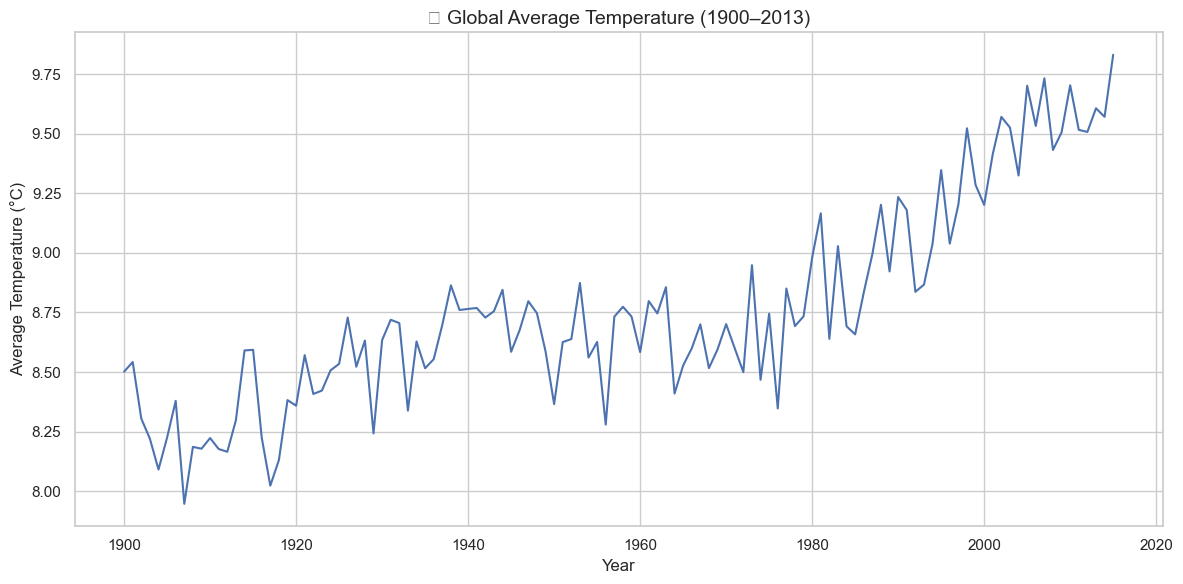

In [17]:
plot_line(global_yearly, 'Year', 'LandAverageTemperature', title="🌍 Global Average Temperature (1900–2013)")


### Country Trend Plot

C:\Users\deeya\AppData\Local\Temp\ipykernel_26420\1233835361.py:8: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\deeya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


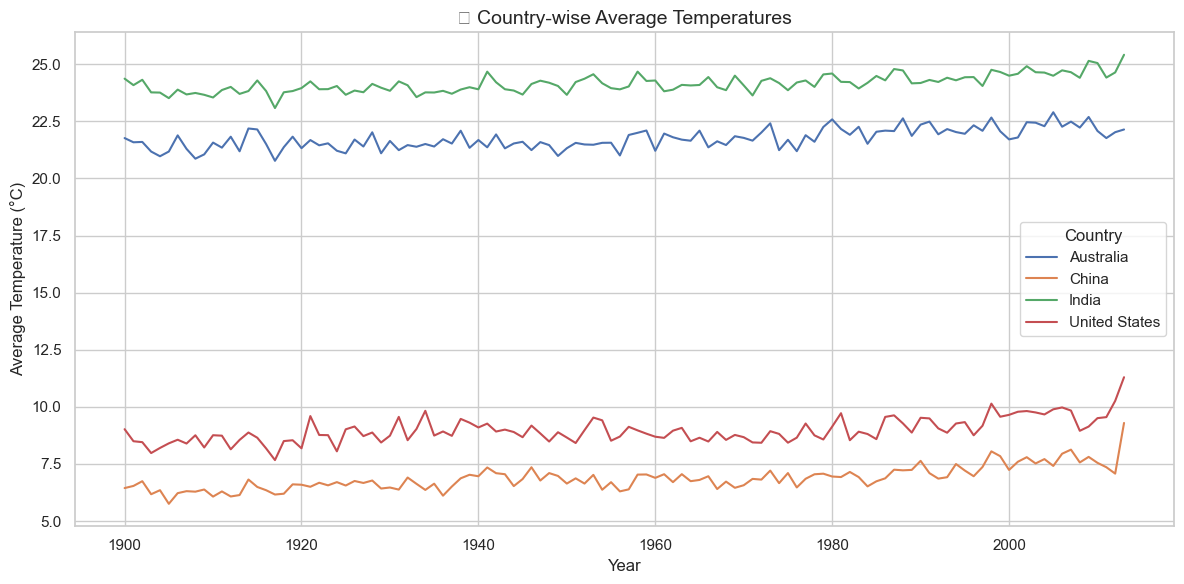

In [18]:
plot_line(country_yearly, 'Year', 'AverageTemperature', hue='Country', title="🌎 Country-wise Average Temperatures")


### City Trend Plot

C:\Users\deeya\AppData\Local\Temp\ipykernel_26420\1233835361.py:8: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\deeya\AppData\Local\Temp\ipykernel_26420\1233835361.py:8: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\deeya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\deeya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


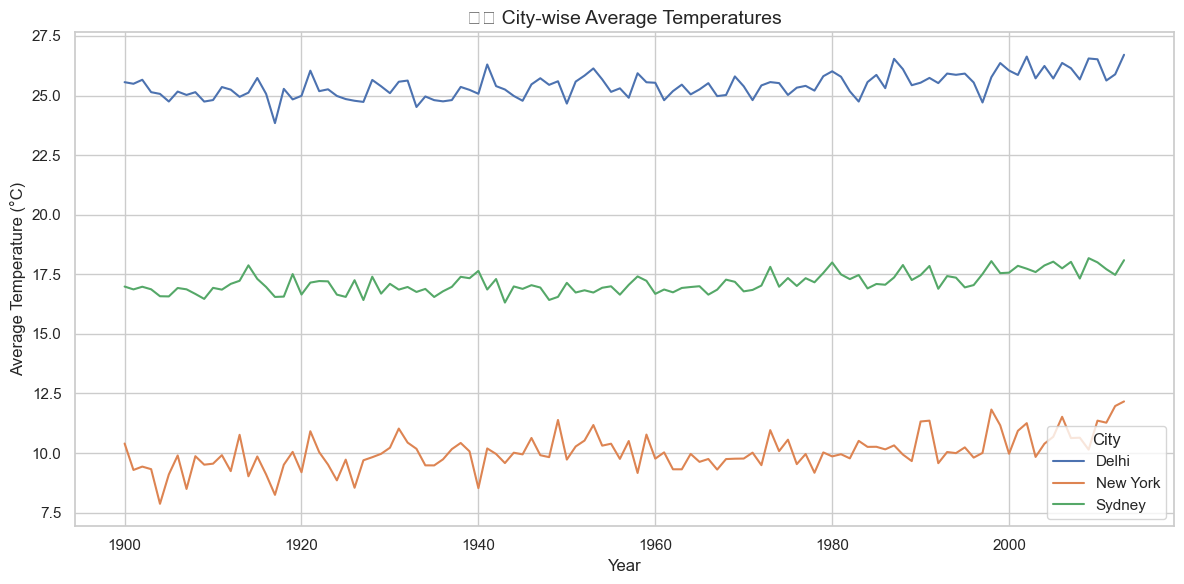

In [19]:
plot_line(city_yearly, 'Year', 'AverageTemperature', hue='City', title="🏙️ City-wise Average Temperatures")


### Major City Trend Plot

C:\Users\deeya\AppData\Local\Temp\ipykernel_26420\1233835361.py:8: UserWarning: Glyph 127750 (\N{CITYSCAPE AT DUSK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\deeya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127750 (\N{CITYSCAPE AT DUSK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


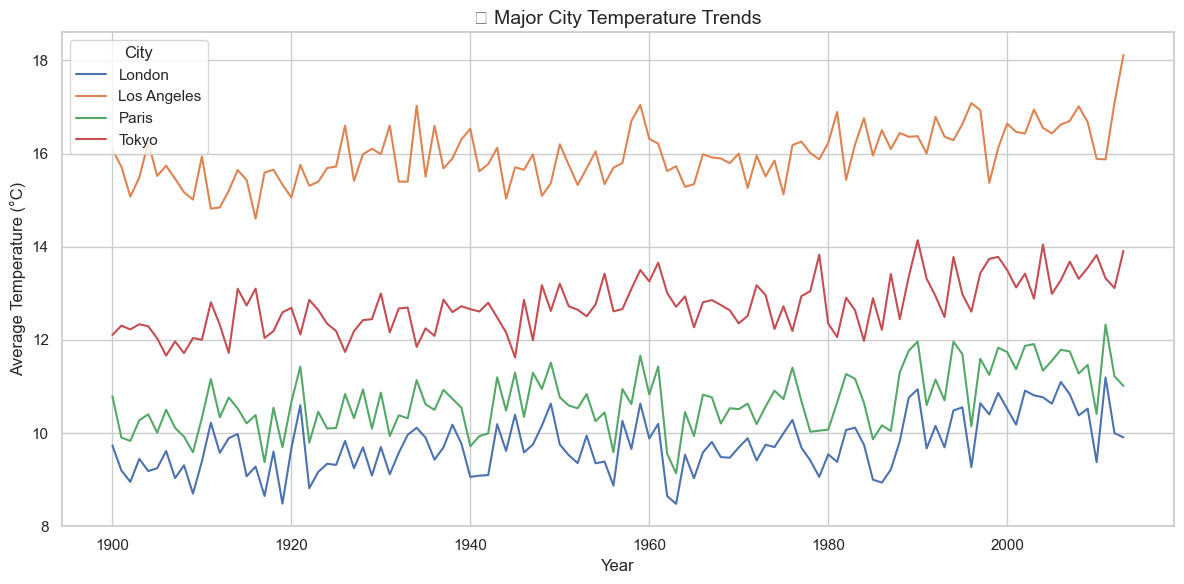

In [20]:
plot_line(major_city_yearly, 'Year', 'AverageTemperature', hue='City', title="🌆 Major City Temperature Trends")


### State Trend Plot

C:\Users\deeya\AppData\Local\Temp\ipykernel_26420\1233835361.py:8: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\deeya\AppData\Local\Temp\ipykernel_26420\1233835361.py:8: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\deeya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\deeya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


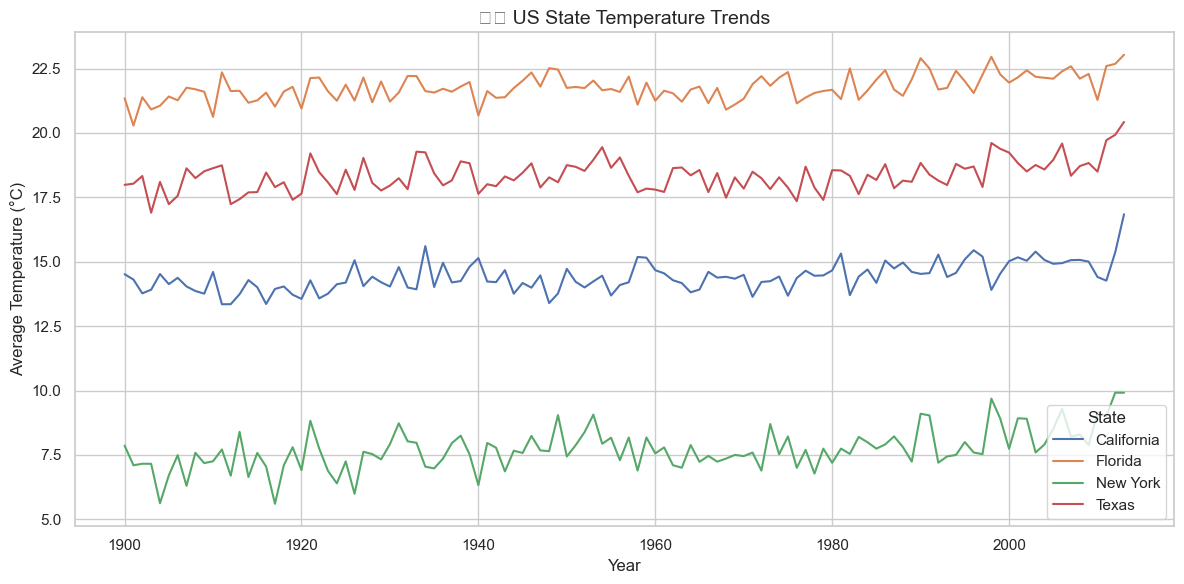

In [21]:
plot_line(state_yearly, 'Year', 'AverageTemperature', hue='State', title="🇺🇸 US State Temperature Trends")

# Interactive Plot

In [22]:
print("\nGenerating interactive Plotly chart for countries...")
fig = px.line(
    country_yearly, x="Year", y="AverageTemperature", color="Country",
    title="📈 Country-wise Temperature Trends (Interactive)"
)
fig.show()



Generating interactive Plotly chart for countries...


# Calculate temperature change

In [23]:
global_yearly['TempChange'] = global_yearly['LandAverageTemperature'].diff()

## Find years with sharp increases (change > threshold)

In [24]:
anomalies = global_yearly[global_yearly['TempChange'] > 0.2]
print("Years with sharp temp rise:")
print(anomalies)

Years with sharp temp rise:
     Year  LandAverageTemperature  TempChange
8    1908                8.186083    0.238917
14   1914                8.590500    0.292750
19   1919                8.382250    0.251417
21   1921                8.571000    0.212250
30   1930                8.633583    0.391167
34   1934                8.628333    0.290083
51   1951                8.625667    0.260417
53   1953                8.873750    0.235500
57   1957                8.732500    0.452917
61   1961                8.797667    0.213917
73   1973                8.948250    0.448667
75   1975                8.744833    0.277333
77   1977                8.850250    0.503000
80   1980                8.980333    0.246917
83   1983                9.028167    0.389000
88   1988                9.201583    0.207167
90   1990                9.234167    0.312167
95   1995                9.347083    0.308333
98   1998                9.522667    0.320083
101  2001                9.414583    0.213417
105  2

In [25]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [26]:
X = global_yearly['Year'].values.reshape(-1, 1)
y = global_yearly['LandAverageTemperature'].values

In [27]:
model = LinearRegression().fit(X, y)
future_years = np.arange(2014, 2031).reshape(-1, 1)
future_preds = model.predict(future_years)

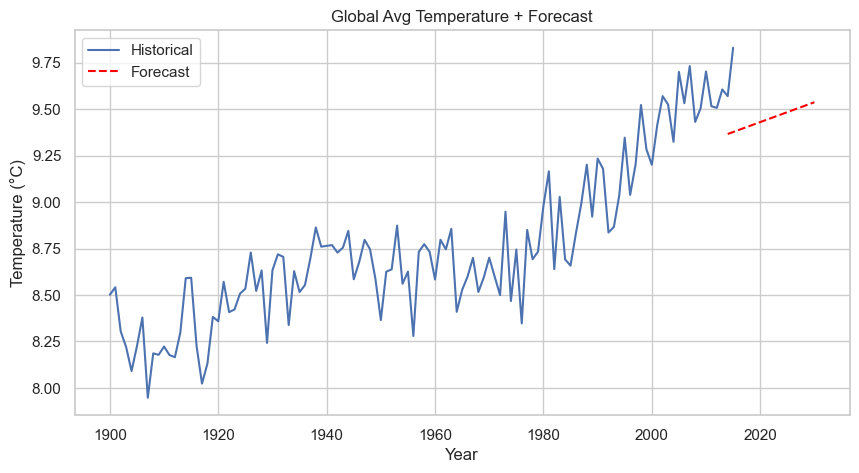

In [28]:
plt.figure(figsize=(10,5))
sns.lineplot(x=global_yearly['Year'], y=y, label='Historical')
plt.plot(future_years, future_preds, label='Forecast', linestyle='--', color='red')
plt.title("Global Avg Temperature + Forecast")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()